In [1]:
%load_ext autoreload
%autoreload 2
import time

import jax
import matplotlib.pyplot as plt

from eci.adapter import SimulationAdapter
from eci.environment import Environment
from eci.visualizer import SimulationVisualizer
from eci.voting_system.plurality import _vote_plurality

In [2]:
NUM_VOTERS = 10
NUM_CANDIDATES = 4
NUM_PREFERENCES = 3
NUM_SIMULATIONS = 50  # the node trajectories

In [3]:
env = Environment(
    num_voters=NUM_VOTERS,
    num_candidates=NUM_CANDIDATES,
    num_preferences=NUM_PREFERENCES,
)
env.num_simulations = NUM_SIMULATIONS

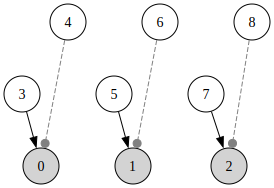

In [4]:
env.network.plot_network()

In [5]:
env.initialize_network()

In [6]:
# intiatialize random key
key = jax.random.PRNGKey(int(time.time()))
## run n simulations
sim = env.run_n_simulation(_vote_plurality, key, NUM_SIMULATIONS)
# update the agents with the results
env._update_agents()
# use result to create dataframe for plotting
env.df = env.create_data_frame()

In [7]:
# 1. Initialisation viz and adapter
viz = SimulationVisualizer()
adapter = SimulationAdapter()

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_54055/3863588151.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


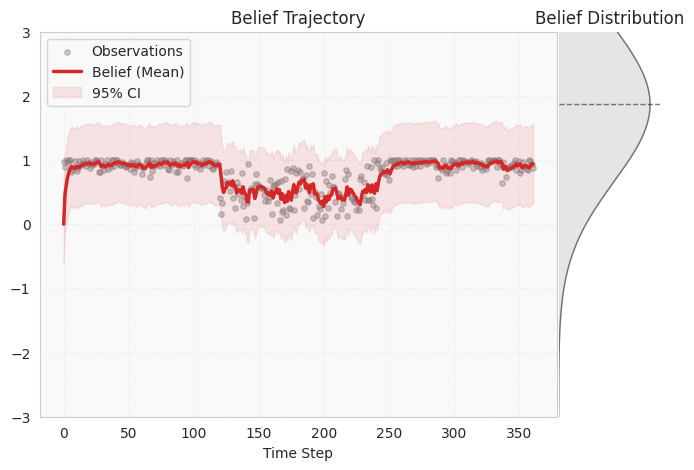

In [8]:
traj_data = adapter.get_voter_trajectory_data(env, voter_id=1)
fig, ax1, ax2 = viz.plot_belief_trajectory(
    **traj_data,
    ylim=(-3, 3),
)
ax1.set_title("Belief Trajectory")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
ax2.set_title("Belief Distribution")
fig.set_size_inches(8, 5)
plt.show()

In [9]:
env.network.attributes[-1]

{'time_step': 0.0,
 'preferences': {'mean': Traced<ShapedArray(float32[3])>with<BatchTrace(level=1/0)> with
    val = Array([[0.31400657, 0.38093805, 0.5138793 ],
         [1.8679295 , 0.33107924, 0.24217987],
         [0.06107831, 0.54067373, 0.7683227 ],
         [0.5488138 , 0.8436756 , 1.7487075 ],
         [0.812943  , 0.8081558 , 0.0160358 ],
         [1.4859877 , 0.6673534 , 1.9020746 ],
         [0.48484278, 1.8728528 , 0.59953666],
         [0.32336307, 1.5073905 , 1.3203707 ],
         [1.4341307 , 0.2307849 , 1.7452588 ],
         [1.1100113 , 1.3133278 , 1.8292611 ]], dtype=float32)
    batch_dim = 0,
  'precision': Traced<ShapedArray(float32[3])>with<BatchTrace(level=1/0)> with
    val = Array([[0.5438616 , 0.94067   , 0.58987224],
         [0.6919236 , 0.9926584 , 0.89460945],
         [0.6263706 , 0.8027519 , 0.66390365],
         [0.87377685, 0.63482183, 0.6819125 ],
         [0.75054955, 0.86077666, 0.798434  ],
         [0.84439635, 0.45027655, 0.6479776 ],
         [

In [10]:
env.last_attributes[0]

{'autoconnection_strength': Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32, weak_type=True),
 'expected_mean': Array([0.93893605, 0.93893605, 0.93893605, 0.93893605, 0.93893605,
        0.93893605, 0.93893605, 0.93893605, 0.93893605, 0.93893605],      dtype=float32),
 'expected_precision': Array([8.36353, 8.36353, 8.36353, 8.36353, 8.36353, 8.36353, 8.36353,
        8.36353, 8.36353, 8.36353], dtype=float32),
 'mean': Array([0.86908984, 0.86908984, 0.86908984, 0.86908984, 0.86908984,
        0.86908984, 0.86908984, 0.86908984, 0.86908984, 0.86908984],      dtype=float32),
 'observed': Array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32),
 'precision': Array([10, 10, 10, 10, 10, 10, 10, 10, 10, 10], dtype=int32, weak_type=True),
 'temp': {'current_variance': Array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],      dtype=float32, weak_type=True),
  'effective_precision': Array([0.16364694, 0.16364694, 0.16364694, 0.16364694, 0.16364694,
         0.16364694, 0.16364694,

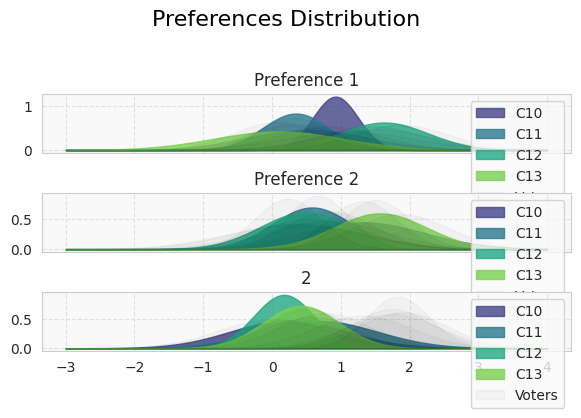

In [11]:
pref_data = adapter.prepare_preference_data(env)
fig, ax1 = viz.plot_preference_distributions(pref_data)
fig.suptitle("Preferences Distribution", fontsize=16)
ax1[0].set_title("Preference 1")
ax1[1].set_title("Preference 2")
fig.set_size_inches(6, 4)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

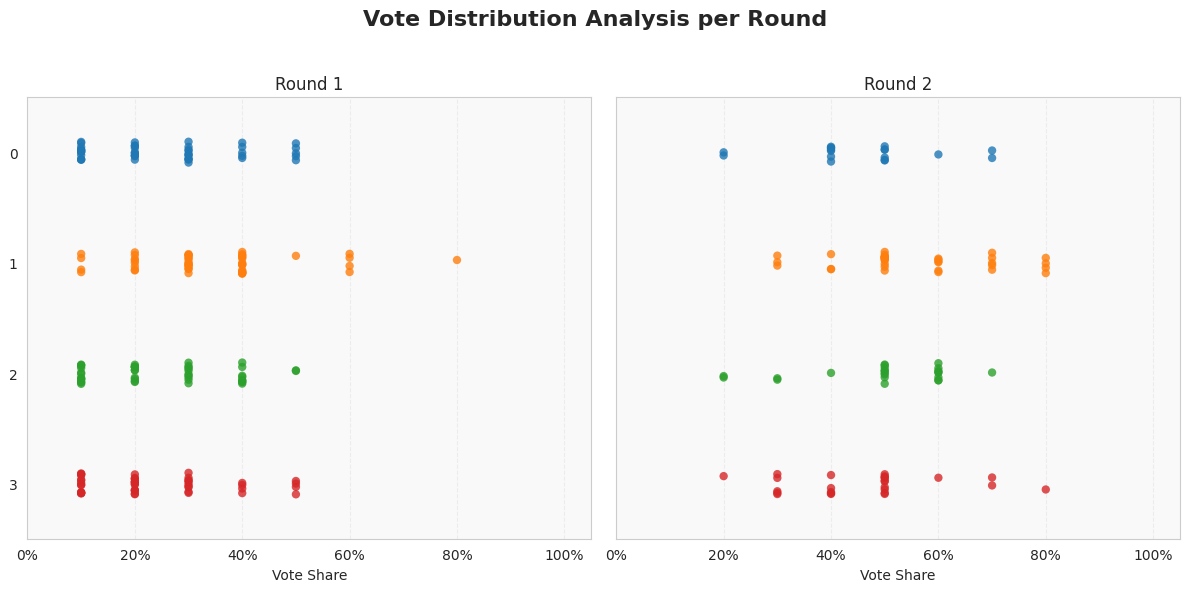

In [12]:
votes_data = adapter.extract_vote_counts(env.df)
fig, axes = viz.plot_vote_proportions(votes_data, plot_kind="stripplot")
plt.show()

In [13]:
# intiatialize random key
key = jax.random.PRNGKey(int(time.time()))
## run n simulations
sim = env.run_n_simulation(
    _vote_plurality, key, NUM_SIMULATIONS
)  # CHANGE BETWEEN MEAN - MEAN
# update the agents with the results
env._update_agents()
# use result to create dataframe for plotting
env.df = env.create_data_frame()

In [14]:
# 1. Initialisation viz and adapter
viz = SimulationVisualizer()
adapter = SimulationAdapter()

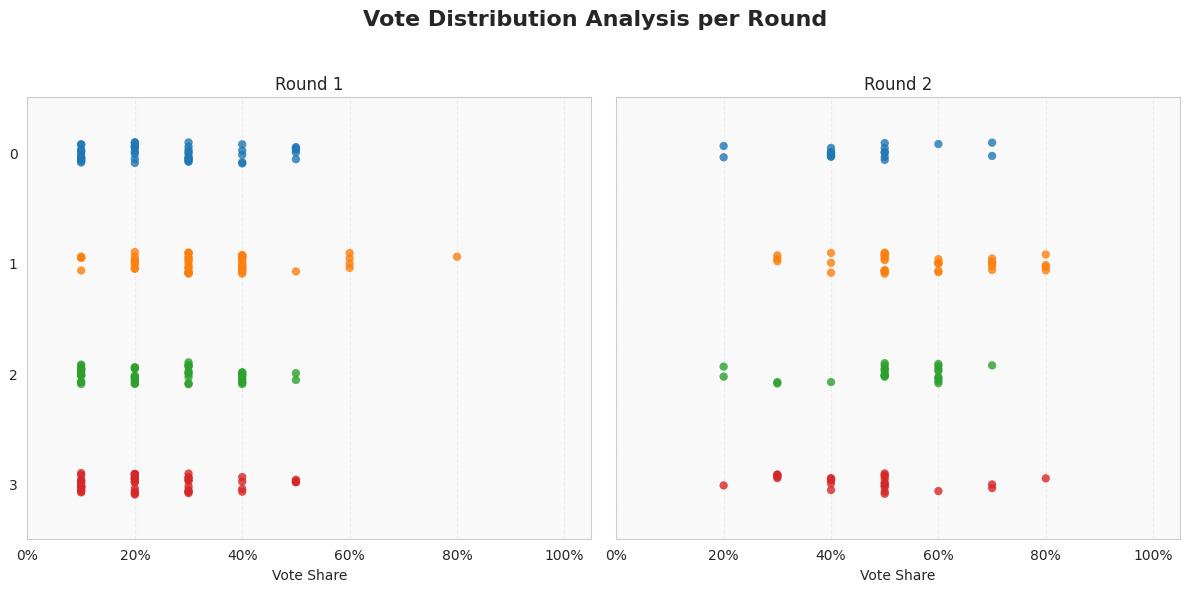

In [15]:
votes_data = adapter.extract_vote_counts(env.df)
fig, axes = viz.plot_vote_proportions(votes_data, plot_kind="stripplot")
plt.show()